In [1]:
import warnings

warnings.filterwarnings("ignore")
# import ST_utils
# import train_STAligner
import STAligner

# the location of R (used for the mclust clustering)
import os
#os.environ['R_HOME'] = "/home/xzhou/anaconda3/envs/PyG/lib/R"
#os.environ['R_USER'] = "/home/xzhou/anaconda3/envs/PyG/lib/python3.8/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy.linalg


import torch

from matplotlib.image import imread

used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [2]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from sklearn.metrics import v_measure_score as v_score
from sklearn.decomposition import PCA

In [3]:
String = 'H'

patho_anno = pd.read_csv(f"../../../data/BreastCancer/her2st-master/data/ST-pat/lbl/{String}1_labeled_coordinates.tsv", index_col=0, sep='\t')


adata_st_list_raw = []

for i in range(1, 4):
    # st_count = pd.read_csv("./data/HER2-positive/count-matrices/E%d.tsv.gz" % i, index_col=0, sep='\t')
    # st_meta = pd.read_csv("./data/HER2-positive/spot-selections/E%d_selection.tsv.gz" % i, sep='\t')
    st_count = pd.read_csv(f"../../..//data/BreastCancer/her2st-master/data/ST-cnts/{String}{i}.tsv.gz", index_col=0, sep='\t')
    st_meta = pd.read_csv(f"../../..//data/BreastCancer/her2st-master/data/ST-spotfiles/{String}{i}_selection.tsv", sep='\t')
    st_meta.index = [str(st_meta['x'][i]) + 'x' + str(st_meta['y'][i]) for i in range(st_meta.shape[0])]
    st_meta = st_meta.loc[st_count.index]
    
    adata_st_i = ad.AnnData(X=st_count.values)
    adata_st_i.obs.index = st_count.index
    adata_st_i.obs = st_meta
    adata_st_i.var.index = st_count.columns
    
    img = imread(f'../../..//data/BreastCancer/her2st-master/data/ST-imgs/{String}/{String}{i}.jpg')
    library_id = 'st'
    adata_st_i.uns["spatial"] = dict()
    adata_st_i.uns["spatial"][library_id] = dict()
    adata_st_i.uns["spatial"][library_id]['images'] = dict()
    adata_st_i.uns["spatial"][library_id]['images']['hires'] = img
    adata_st_i.uns["spatial"][library_id]['images']['lowres'] = img
    adata_st_i.uns["spatial"][library_id]['scalefactors'] = {'spot_diameter_fullres': 100,
                                                             'tissue_hires_scalef': 1.0,
                                                             'fiducial_diameter_fullres': 100,
                                                             'tissue_lowres_scalef': 1.0}
    
    adata_st_i.obsm['spatial'] = np.concatenate((np.array(st_meta["pixel_x"]).reshape(-1,1),
                                                 np.array(st_meta["pixel_y"]).reshape(-1,1)), axis=1)

    adata_st_i.obsm['loc_use'] = np.concatenate((np.array(st_meta["x"]).reshape(-1,1),
                                                 np.array(st_meta["y"]).reshape(-1,1)), axis=1)
    adata_st_i.obs['array_row'] = adata_st_i.obs["x"].values
    adata_st_i.obs['array_col'] = adata_st_i.obs["y"].values
    adata_st_i.obs['st_sample'] = String + str(i)

    if i == 1:
        adata_st_i.obs['annotation'] = None
        for idx in adata_st_i.obs.index:
            adata_st_i.obs['annotation'].loc[idx] = patho_anno[(patho_anno["x"] == adata_st_i[idx].obs["new_x"].values[0]) &
                                                               (patho_anno["y"] == adata_st_i[idx].obs["new_y"].values[0])]['label'].values[0]
    else:
        adata_st_i.obs['annotation'] = "Unknown"
    
    print(f'Slice {String}{i} spots:' + str(len(adata_st_i.obs)))

    adata_st_list_raw.append(adata_st_i)

Slice H1 spots:613
Slice H2 spots:603
Slice H3 spots:510


In [4]:
adata_st_list_raw

[AnnData object with n_obs × n_vars = 613 × 15029
     obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use',
 AnnData object with n_obs × n_vars = 603 × 14907
     obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use',
 AnnData object with n_obs × n_vars = 510 × 14873
     obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use']

In [5]:
section_ids = []
for i in range(1,4):
    slice_id = String + str(i)
    section_ids.append(slice_id)
section_ids

['H1', 'H2', 'H3']

In [6]:
Batch_list = []
adj_list = []

for i, section_id in enumerate(section_ids):
    print(section_id)
    adata = adata_st_list_raw[i]
    # input_dir = os.path.join('../../../data/DLPFC', section_id)
    # adata = sc.read_visium(path=input_dir, count_file=section_id + '_filtered_feature_bc_matrix.h5', load_images=True)
    # adata.var_names_make_unique(join="++")
    # 
    # # read the annotation
    # Ann_df = pd.read_csv(os.path.join(input_dir, 'manual_annotations.txt'), sep='\t', header=None, index_col=0)
    # Ann_df.columns = ['Ground Truth']
    # Ann_df[Ann_df.isna()] = "unknown"
    # adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth'].astype('category')
    
    #make spot name unique
    adata.obs_names = [x+'_'+section_id for x in adata.obs_names]
    
    # Constructing the spatial network
    STAligner.Cal_Spatial_Net(adata, rad_cutoff=350) # the spatial network are saved in adata.uns[‘adj’]
    # STAligner.Stats_Spatial_Net(adata) # plot the number of spatial neighbors
    
    # Normalization
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=1000)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata = adata[:, adata.var['highly_variable']]

    adj_list.append(adata.uns['adj'])
    Batch_list.append(adata)

H1
------Calculating spatial graph...
The graph contains 2318 edges, 613 cells.
3.7814 neighbors per cell on average.
H2
------Calculating spatial graph...
The graph contains 2282 edges, 603 cells.
3.7844 neighbors per cell on average.
H3
------Calculating spatial graph...
The graph contains 1864 edges, 510 cells.
3.6549 neighbors per cell on average.


In [7]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs['annotation'] = adata_concat.obs['annotation'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (1726, 184)


In [8]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(section_ids)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

In [9]:
%%time
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 50, device=used_device)

STAligner(
  (conv1): GATConv(184, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 184, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:01<00:00, 269.01it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

Update spot triplets at epoch 800


 79%|███████▉  | 395/500 [00:03<00:00, 151.15it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [00:04<00:00, 111.63it/s]

CPU times: total: 10.6 s
Wall time: 6.49 s


In [10]:
STAligner.ST_utils.mclust_R(adata_concat, num_cluster=6, used_obsm='STAligner')
adata_concat = adata_concat[adata_concat.obs['annotation']!='unknown']

sub_adata = adata_concat[adata_concat.obs['batch_name'] == String+str('1')]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
print(f"total AMI:{AMI}")
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
print(f"total COM:{COM}")
V =  2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
total ARI:0.29155143739811673
total NMI:0.44063912356646207
total AMI:0.43192651226478534
total HOM:0.40876320611752437
total COM:0.4779069666322118
total V:0.4406391235664621


2.3775382583073323


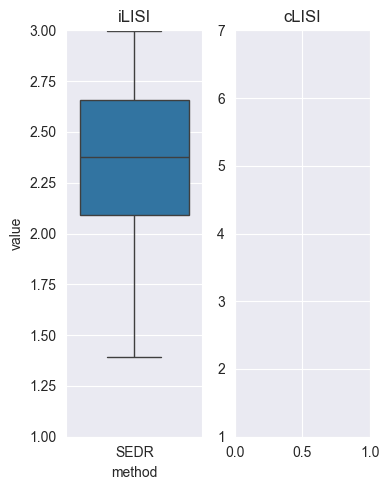

In [11]:
import harmonypy as hm

iLISI = hm.compute_lisi(adata_concat.obsm['STAligner'], adata_concat.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
#cLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'SEDR',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
#sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
#print(np.median(cLISI))

In [12]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

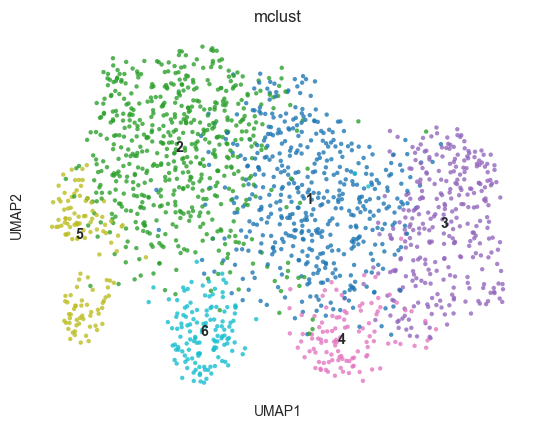

In [13]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pp.neighbors(adata_concat, use_rep='STAligner', metric='cosine', n_neighbors=15)  # 可调整 n_neighbors
sc.tl.umap(adata_concat)  # 调整 min_dist 参数优化聚类

sc.pl.umap(
    adata_concat, 
    color=['mclust'], 
    size=40,  # 调整点大小
    alpha=0.8,  # 调整透明度
    palette='tab10',  # 自定义调色板
    legend_loc='on data'
)

In [14]:
custom_palette1 = {
    1: '#5b819b',  
    2: '#946943',  
    3: '#649b64',  
    4: '#8d5353',  
    5: '#655573',  
    6: '#8a736e'
}

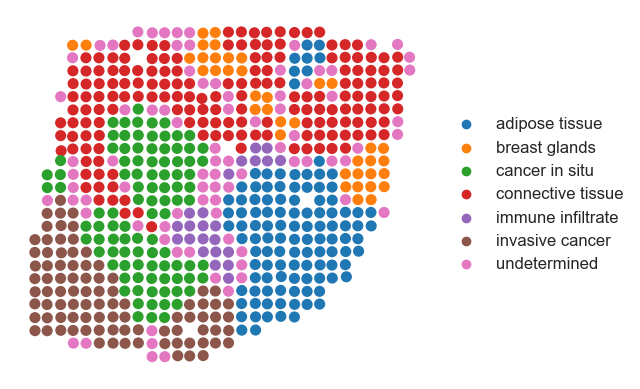

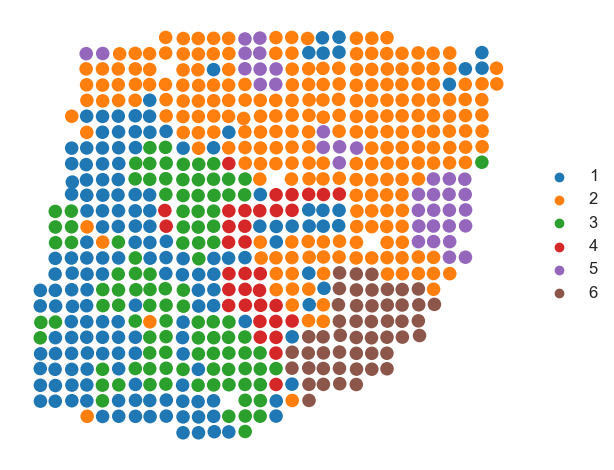

In [15]:
import matplotlib.pyplot as plt


adata_tmp_A1 = adata_concat[adata_concat.obs['batch_name'] == String+str(1)]
adata_tmp_A1.uns = adata_st_list_raw[1].uns

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['annotation'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['mclust'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='annotation',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='mclust',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

plt.tight_layout()

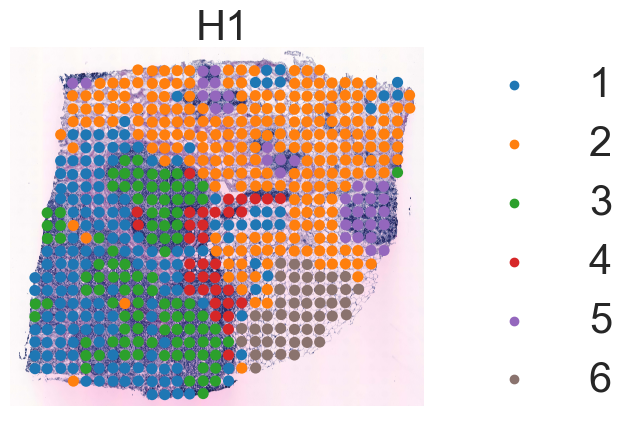

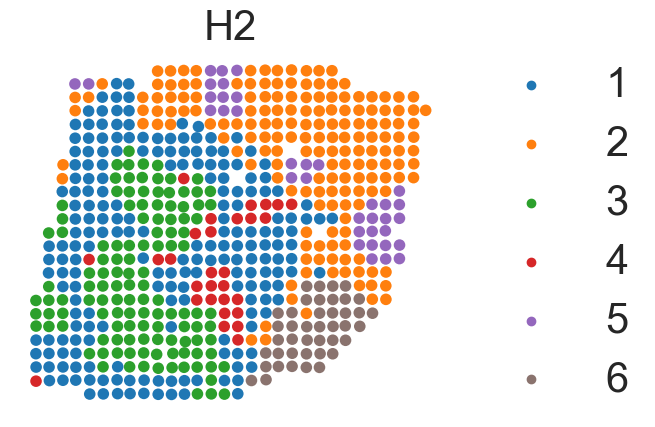

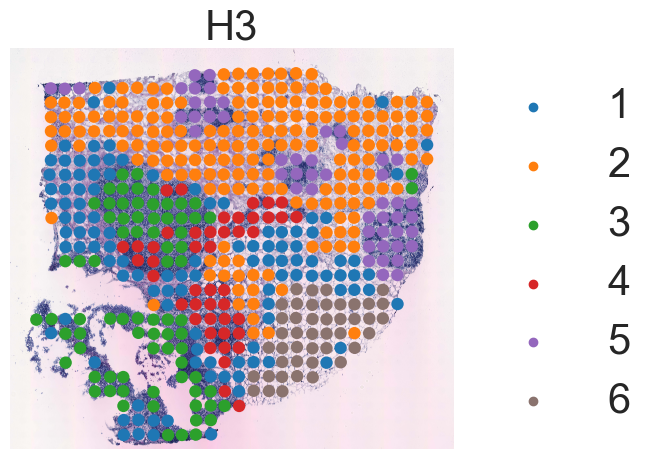

In [16]:
import matplotlib.pyplot as plt

cluster_colors = {
    1: '#1f77b4',  # Cluster 0 -> 蓝色
    2: '#ff7f0e',  # Cluster 1 -> 橙色
    3: '#2ca02c',  # Cluster 2 -> 绿色
    4: '#d62728',  # Cluster 3 -> 红色
    5: '#9467bd',  # Cluster 4 -> 紫色
    6: '#8a736e'   # Cluster 5 -> 
}


for i, slice_name in enumerate(section_ids):
    adata_tmp = adata_concat[adata_concat.obs['batch_name'] == String+str(i+1)]
    adata_tmp.uns = adata_st_list_raw[i].uns
    sc.pl.spatial(adata_tmp, img_key='hires', color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=30, show=False, frameon=False, spot_size=250,
                  palette=cluster_colors)
    plt.title(f'{slice_name}', fontsize=30)
    plt.savefig(f"D:\\njy\MutipelSliceSTD\MS\论文图表设计\Figure8_BC\FS12\\{String}\STAligner_{i+1}.jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()